---

# Flower Species Classification with K-Nearest Neighbors

K-Nearest Neighbors (kNN) is a simple but powerful supervised learning algorithm that classifies a new data point based on the majority class of its k closest neighbors in the training set. It makes no assumptions about the underlying data distribution, making it a flexible non-parametric method.

In this notebook, we apply kNN to the Iris dataset to classify flowers into three species — setosa, versicolor, and virginica — based on their sepal and petal measurements.

---

In [16]:
# Standard data manipulation and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Our own KNN implementation from ml_pack
from ml_pack import KNN

# Sklearn tools for preprocessing and evaluation only
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

---

## Loading and Exploring the Data

---

In [17]:
# Load the Iris dataset
df = pd.read_csv("iris.csv")

# Check dimensions and preview
print(df.shape)
df.head()

(150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [18]:
# Check class distribution and data types
print(df.info())
print()
print("Class distribution:")
print(df['species'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None

Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


---

## Defining Features and Target

---

In [19]:
# Separate features and target
X = df.drop(columns='species').values
y = df['species'].values

print("Feature matrix shape:", X.shape)
print("Classes:", np.unique(y))

Feature matrix shape: (150, 4)
Classes: ['setosa' 'versicolor' 'virginica']


---

## Splitting and Scaling the Data

---

In [20]:
# Split into 80% training and 20% test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardize features — kNN relies on distance so scaling is critical
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set size:", X_train_scaled.shape)
print("Test set size:", X_test_scaled.shape)

Training set size: (120, 4)
Test set size: (30, 4)


---

## Finding the Optimal k

We test a range of k values and plot the test accuracy for each to find the best k.

---

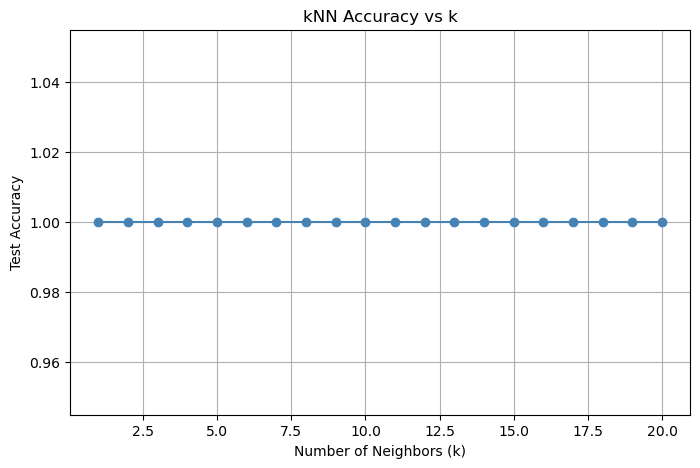

Best k: 1 with accuracy 1.000


In [21]:
# Test k values from 1 to 20 using our ml_pack KNN
k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn = KNN(k=k)
    knn.fit(X_train_scaled, y_train)
    accuracies.append(knn.score(X_test_scaled, y_test))

# Plot accuracy vs k
plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker='o', color='steelblue')
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Test Accuracy")
plt.title("kNN Accuracy vs k")
plt.grid(True)
plt.show()

print(f"Best k: {list(k_values)[np.argmax(accuracies)]} with accuracy {max(accuracies):.3f}")

---

## Training and Evaluating the Model

We train the final model using k=5, which is more robust than k=1 since it's less sensitive to noise in the training data.

---

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



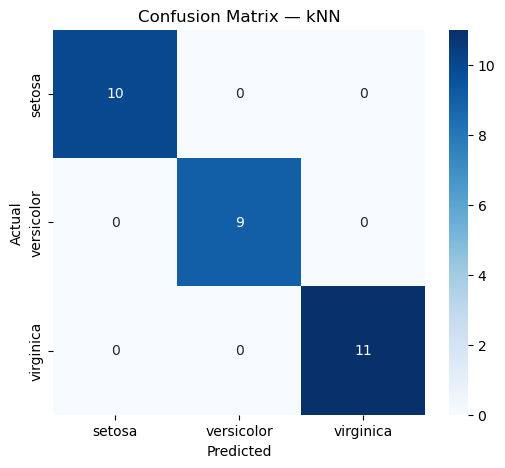

In [22]:
# Train final model with k=5
knn = KNN(k=5)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)

# Print classification report
print(classification_report(y_test, y_pred, target_names=['setosa', 'versicolor', 'virginica']))

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['setosa', 'versicolor', 'virginica'],
            yticklabels=['setosa', 'versicolor', 'virginica'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — kNN")
plt.show()

---

## Summary

In this notebook we applied k-Nearest Neighbors to classify iris flowers into three species based on sepal and petal measurements. The model achieved 100% accuracy on the test set with k=5.

Key takeaways:
- kNN makes no assumptions about the data distribution — it simply memorizes the training set
- Feature scaling is critical since kNN relies entirely on distance calculations
- Smaller k values are more sensitive to noise while larger k values produce smoother decision boundaries
- The Iris dataset is linearly separable enough that even simple models achieve perfect classification

---